<!-- 

 © Copyright IBM Corporation 2025-2026

 SPDX-License-Identifier: Apache-2.0

 -->



# TerraKit: Climate Data Store search and query



Use the TerraKit Climate Data Store Data Connector to search and query data from [CDS](https://cds.climate.copernicus.eu/datasets/). Available collections include:



 - [ERA5 post-processed daily statistics on single levels from 1940 to present](https://cds.climate.copernicus.eu/datasets/derived-era5-single-levels-daily-statistics?tab=overview)

 - [CORDEX regional climate model data on single levels](https://cds.climate.copernicus.eu/datasets/projections-cordex-domains-single-levels?tab=overview)



<div class="alert alert-block alert-success">

<b>Install TerraKit</b> For instructions on how to install TerraKit, take a look at the <a href="https://terrastackai.github.io/terrakit/">Welcome</a> page.

</div>

In [3]:
import matplotlib.pyplot as plt

from terrakit import DataConnector

from terrakit.general_utils.plotting import (
    plot_era5_variable,
    plot_era5_variables_comparison,
    plot_cordex_variable,
    plot_cordex_variables_comparison,
)

### Create an account

Create an account at [https://cds.climate.copernicus.eu/](https://cds.climate.copernicus.eu/). Once created, find your API  key under the `Profile` section. Each dataset may also require accepting the licence agreement. If this is the case, the first time a request is made, an error will be returned with the url to visit to accept the terms.

### Connect to CDS

In [4]:
data_connector = "climate_data_store"
dc = DataConnector(connector_type=data_connector)
dc.connector.list_collections()

2026-04-20 15:04:37,537 - INFO - Initializing DataConnector with connector type: climate_data_store
2026-04-20 15:04:37,537 - INFO - climate_data_store
2026-04-20 15:04:37,539 - INFO - climate_data_store
2026-04-20 15:04:37,541 - INFO - Listing available collections


['projections-cordex-domains-single-levels',
 'derived-era5-single-levels-daily-statistics']

TerraKit defines a bounding box as a list using the format `[min_lon, min_lat, max_lon, max_lat]`, which is equivalent to `[West, South, East, North]`. Let's do that!

In [5]:
# Small area over Western Europe [min_lon, min_lat, max_lon, max_lat]
bbox = [-10, 40, 5, 50]  # [West, South, East, North]

## Derived ERA5 Single Levels Daily Statistics

Now we can search for data from the Derived ERA5 Single Levels Daily Statistics collection.



The `find_data()` function will search for data and return both a list of unique dates where data is available, but also the raw results from the search.

In [9]:
collection_name = "derived-era5-single-levels-daily-statistics"
date_start = "2024-01-01"
date_end = "2024-01-03"  # 3 days for quick testing

# Variables covering all 4 parameter classes
bands = [
    # Instantaneous
    "2m_temperature",
    "10m_u_component_of_wind",
    "mean_sea_level_pressure",
    # Accumulated
    "total_precipitation",
    "surface_net_solar_radiation",
    "evaporation",
    # Mean rate
    "mean_total_precipitation_rate",
    # Min/Max
    "maximum_2m_temperature_since_previous_post_processing",
    "minimum_2m_temperature_since_previous_post_processing",
]

# Additional query parameters
query_params = {
    "daily_statistic": "daily_mean",
    "time_zone": "utc+00:00",
    "frequency": "1_hourly",
}

Now to query the data, we specify the bands we want to return, plus an (optional) save filename. The `get_data()` function will query the data from the data source and return an **xarray.Dataset** containing all the fetched data. Each variable is a separate data variable with dimensions (time, latitude, longitude), and each variable includes a `stepType` attribute indicating its parameter class.

**Important**: The method now returns `xarray.Dataset` (not `DataArray`) to preserve parameter class (stepType) information for each variable.

**Climate Data Storage**: Climate data is saved as a single time-series NetCDF file containing all requested variables across all time steps. This approach is optimal for climate analysis, which typically requires examining long-term temporal patterns rather than individual daily snapshots. If `save_file='output.nc'` is provided, all data will be saved in one file, facilitating temporal analysis and reducing file management overhead.

In [7]:
save_filestem = f"./tmp_download/{data_connector}_{collection_name}"

ds = dc.connector.get_data(
    data_collection_name=collection_name,
    date_start=date_start,
    date_end=date_end,
    bbox=bbox,
    bands=bands,
    query_params=query_params,
    save_file=f"{save_filestem}.nc",
)

# Note: get_data() now returns an xarray.Dataset (not DataArray)
# Each variable is a data variable with its own stepType attribute
print(f"Downloaded {len(ds.data_vars)} variables: {list(ds.data_vars)}")
print(f"Time steps: {len(ds.time)}")
print(
    f"Spatial dimensions: {len(ds.latitude)} latitudes x {len(ds.longitude)} longitudes"
)

2026-04-20 15:04:42,822 - INFO - Submitting CDS request for derived-era5-single-levels-daily-statistics
2026-04-20 15:04:42,823 - INFO - Date range: 2024-01-01 to 2024-01-03 (3 days)
2026-04-20 15:04:42,823 - INFO - Area: 1306839.4 km²
2026-04-20 15:04:42,823 - INFO - Variables: 9
2026-04-20 15:04:42,824 - INFO - Estimated size: ~352.85 MB
2026-04-20 15:04:42,824 - INFO - Estimated time: ~72.6 minutes


1940-01-01 00:00:00 2026-02-04 00:00:00


2026-04-20 15:04:43,064 - INFO - Request submitted to CDS queue. Please wait...
2026-04-20 15:04:43,417 INFO Request ID is 174b0657-b3dc-4d60-a779-7dda460015f7
2026-04-20 15:04:43,417 - INFO - Request ID is 174b0657-b3dc-4d60-a779-7dda460015f7
2026-04-20 15:04:45,097 INFO status has been updated to accepted
2026-04-20 15:04:45,097 - INFO - status has been updated to accepted
2026-04-20 15:04:54,458 INFO status has been updated to running
2026-04-20 15:04:54,458 - INFO - status has been updated to running
2026-04-20 15:06:43,589 INFO status has been updated to successful
2026-04-20 15:06:43,589 - INFO - status has been updated to successful
2026-04-20 15:06:43,728 - INFO - Downloading https://object-store.os-api.cci2.ecmwf.int:443/cci2-prod-cache-1/2026-04-20/7c50f95fb9cc4da9ad47b9fa1b418995.zip


7c50f95fb9cc4da9ad47b9fa1b418995.zip:   0%|          | 0.00/383k [00:00<?, ?B/s]

2026-04-20 15:06:44,574 - INFO - ✓ Download complete: cds_derived-era5-single-levels-daily-statistics_20260420_150443.zip
2026-04-20 15:06:44,574 - INFO - Actual time: 2.0 minutes
2026-04-20 15:06:44,937 - INFO - Saved time-series NetCDF: ./tmp_download/climate_data_store_derived-era5-single-levels-daily-statistics.nc (3 time steps from 2024-01-01 to 2024-01-03, 9 variables)
2026-04-20 15:06:44,938 - INFO - Processed 3 time steps and 9 variables into Dataset


Downloaded 9 variables: ['10m_u_component_of_wind', 'evaporation', 'mean_sea_level_pressure', 'mean_total_precipitation_rate', 'mn2t', 'mx2t', 'surface_net_solar_radiation', 't2m', 'total_precipitation']
Time steps: 3
Spatial dimensions: 41 latitudes x 61 longitudes


### Inspect the Dataset

Let's examine the structure of the returned Dataset and the stepType attributes:

In [10]:
# Display dataset structure
print("Dataset structure:")
print(ds)

# Show stepType for each variable
print("\nVariable stepTypes:")
for var_name in ds.data_vars:
    step_type = ds[var_name].attrs.get("GRIB_stepType", "unknown")
    print(f"  {var_name}: {step_type}")

Dataset structure:
<xarray.Dataset> Size: 271kB
Dimensions:                        (latitude: 41, longitude: 61, time: 3)
Coordinates:
  * latitude                       (latitude) float64 328B 50.0 49.75 ... 40.0
  * longitude                      (longitude) float64 488B -10.0 -9.75 ... 5.0
  * time                           (time) datetime64[ns] 24B 2024-01-01 ... 2...
    number                         int64 8B ...
    valid_time                     datetime64[ns] 8B 2024-01-01
    spatial_ref                    int64 8B 0
Data variables:
    10m_u_component_of_wind        (time, latitude, longitude) float32 30kB 9...
    evaporation                    (time, latitude, longitude) float32 30kB -...
    mean_sea_level_pressure        (time, latitude, longitude) float32 30kB 9...
    mean_total_precipitation_rate  (time, latitude, longitude) float32 30kB 0...
    mn2t                           (time, latitude, longitude) float32 30kB 2...
    mx2t                           (time, lati

## Visualizing the Data

Now let's visualize the data we downloaded. We'll create plots for each variable and time step.

The plotting functions below work with the new Dataset format and display the stepType information for each variable.

### Plot a Single Variable

Let's visualize the first variable for the first time step:

Plotting: 10m_u_component_of_wind


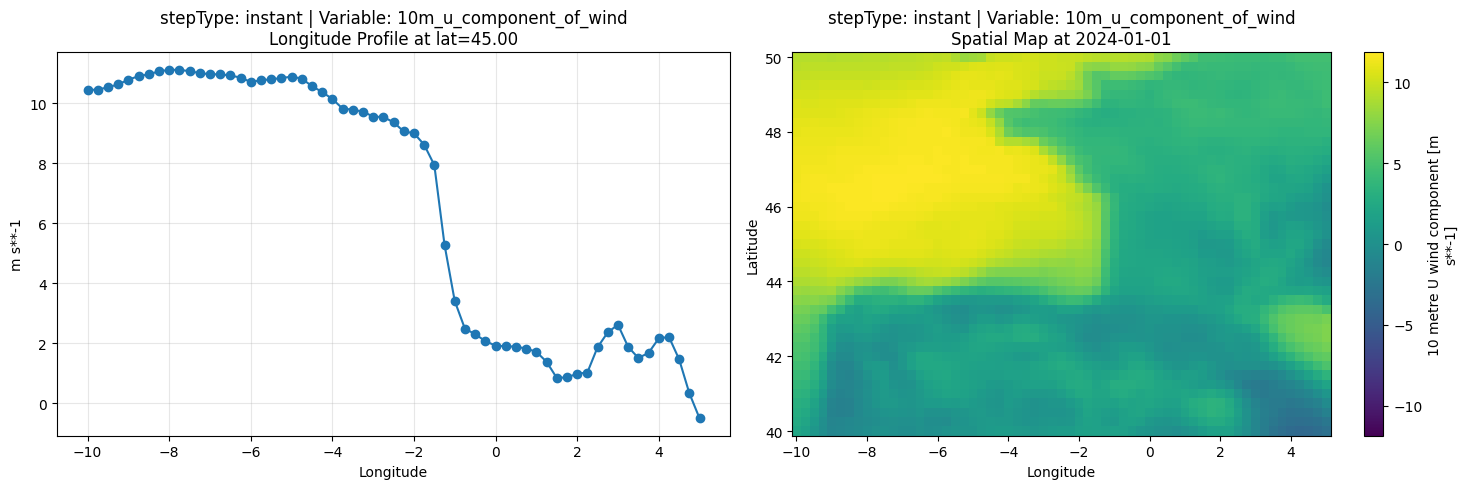

In [11]:
# Get the first variable name from the dataset
first_var = list(ds.data_vars)[0]
print(f"Plotting: {first_var}")

# Plot the first variable for the first time step
fig = plot_era5_variable(ds, first_var, time_index=0)
plt.show()

### Plot All Variables

Now let's create a comprehensive view of all variables for the first day:

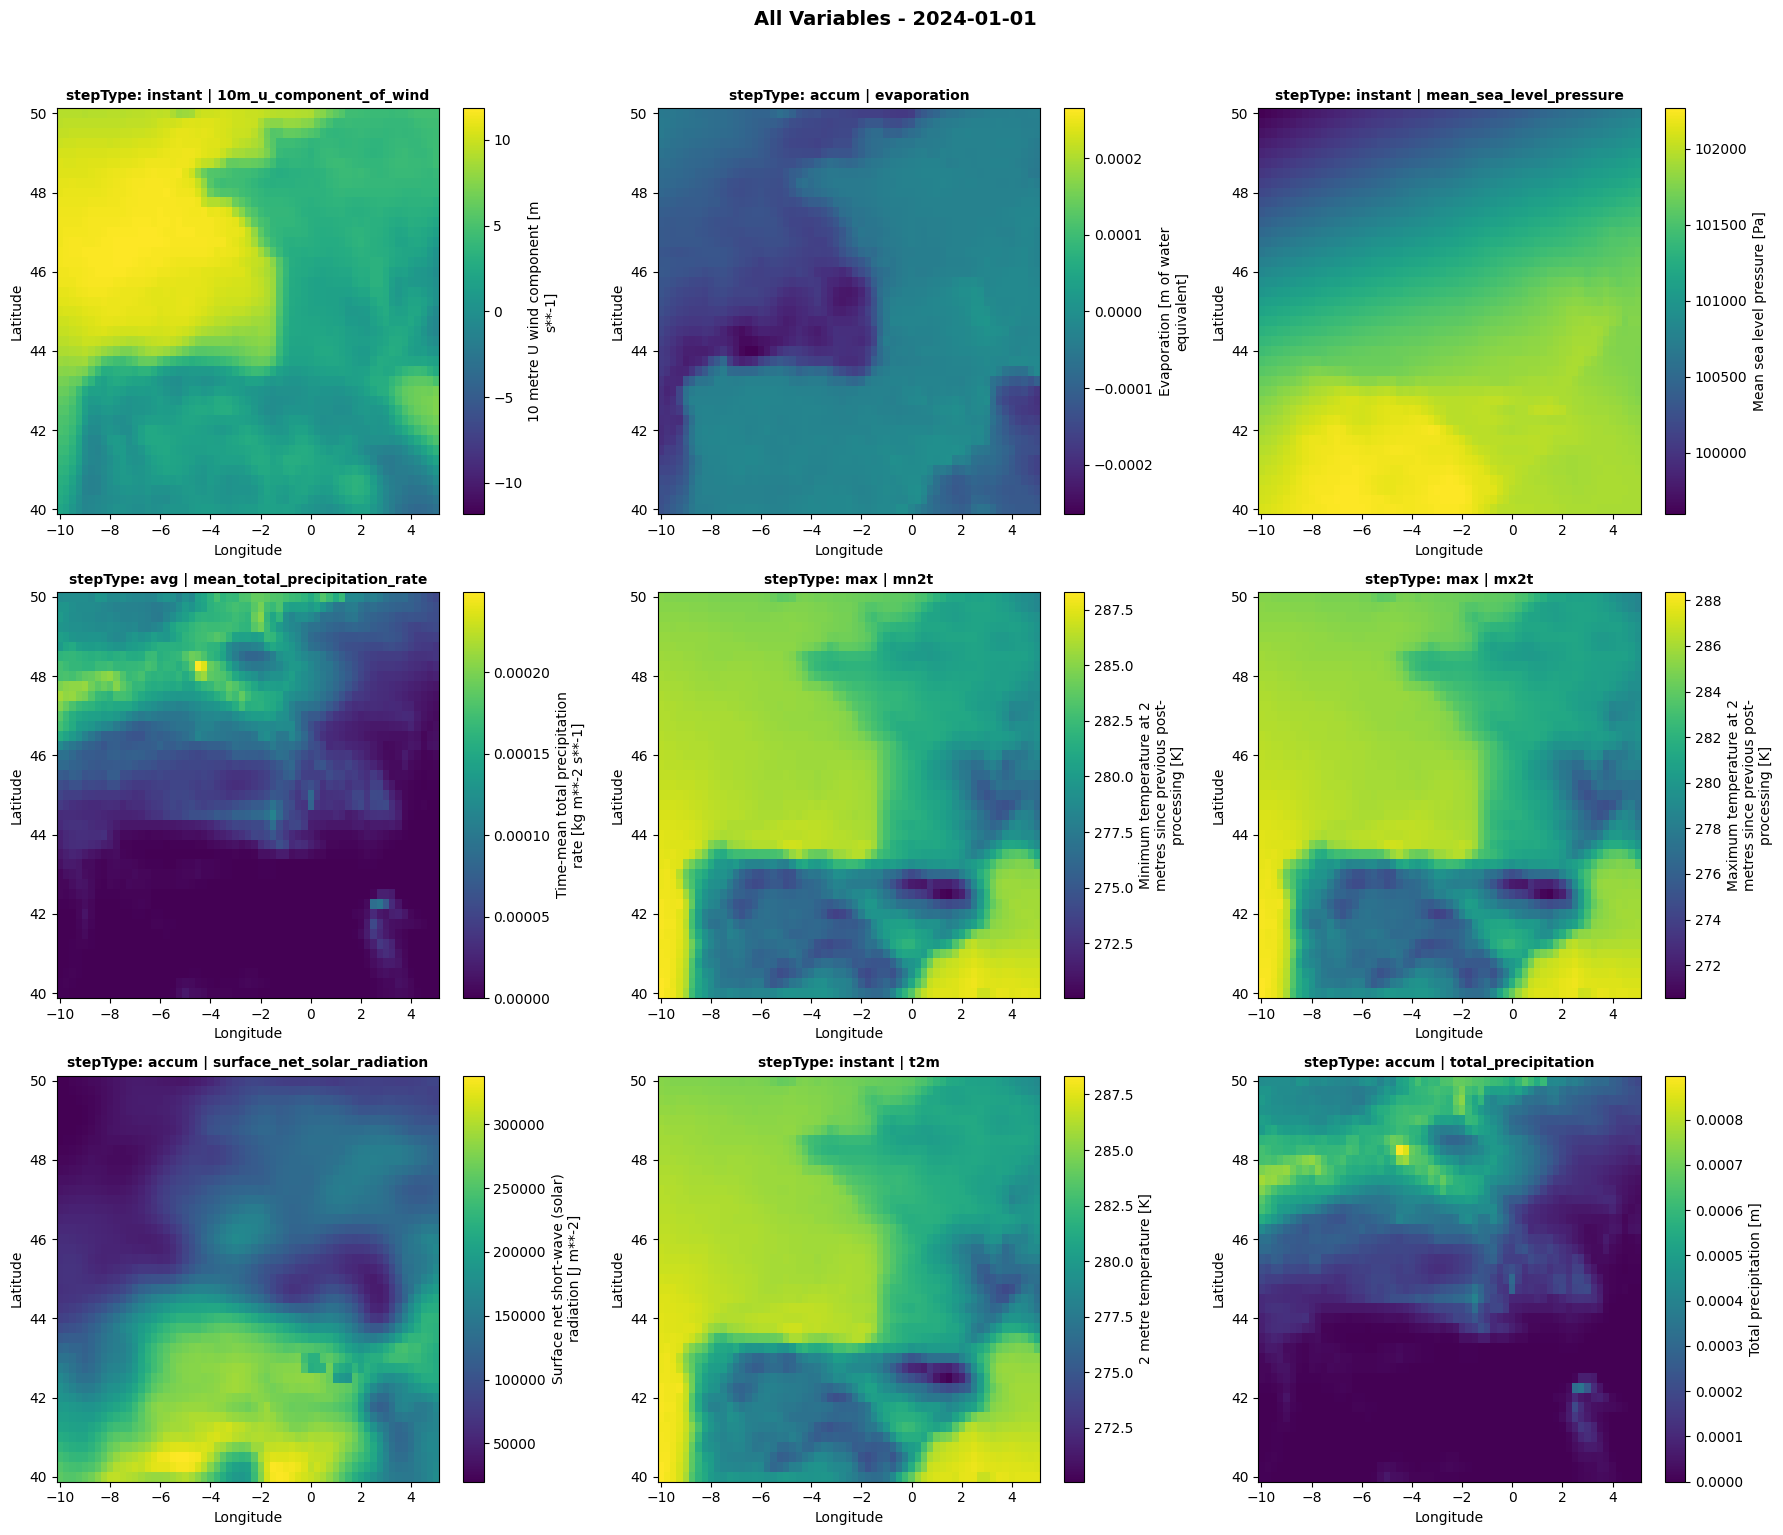

In [12]:
# Plot all variables for the first day
fig = plot_era5_variables_comparison(ds, time_index=0)
plt.show()

## Projections CORDEX Domains Single Levels

Now we can search for data from the Projections CORDEX Single Levels collection.

The `find_data()` function will search for data and return both a list of unique dates where data is available, but also the raw results from the search.

In [22]:
bbox = [20, -10, 30, 0]  # Africa region

In [16]:
collection_name = "projections-cordex-domains-single-levels"
date_start = "1950-01-01"
date_end = "1950-01-03"  # 3 days for quick testing

# Variables covering all 4 parameter classes
bands = [
    "10m_wind_speed",
    "2m_air_temperature",
    "mean_precipitation_flux",
]

query_params = {
    "experiment": "historical",
    "gcm_model": "ichec_ec_earth",
    "rcm_model": "knmi_racmo22t",
    "ensemble_member": "r1i1p1",
    "temporal_resolution": "daily_mean",
    "horizontal_resolution": "0_44_degree_x_0_44_degree",
}

Now to query the data, we specify the bands we want to return, plus an (optional) save filename. The `get_data()` function will query the data from the data source and return an **xarray.Dataset** containing all the fetched data. Each variable is a separate data variable with dimensions (time, rlat, rlon) for CORDEX data using rotated pole coordinates.


**Climate Data Storage**: Climate data is saved as a single time-series NetCDF file containing all requested variables across all time steps. If `save_file='output.nc'` is provided, all data will be saved in one file, facilitating temporal analysis and reducing file management overhead.

In [ ]:
save_filestem = f"./tmp_download/{data_connector}_{collection_name}"

ds = dc.connector.get_data(
    data_collection_name=collection_name,
    date_start=date_start,
    date_end=date_end,
    bbox=bbox,
    bands=bands,
    query_params=query_params,
    save_file=f"{save_filestem}.nc",
)

# Note: get_data() now returns an xarray.Dataset (not DataArray)
# Each variable is a data variable with its own stepType attribute
print(f"Downloaded {len(ds.data_vars)} variables:")
for var_name in ds.data_vars:
    print(f"\t {var_name}: {ds[var_name].attrs.get('long_name', 'N/A')}")
print(f"Time steps: {len(ds.time)}")

# CORDEX data uses rotated pole coordinates (rlat/rlon) instead of latitude/longitude
# Get the actual dimension names from the dataset
spatial_dims = [
    dim
    for dim in ds.dims
    if dim in ["latitude", "longitude", "lat", "lon", "rlat", "rlon", "x", "y"]
]
if "rlat" in ds.dims and "rlon" in ds.dims:
    print(
        f"Spatial dimensions (rotated pole): {len(ds.rlat)} rlat x {len(ds.rlon)} rlon"
    )
elif "latitude" in ds.dims and "longitude" in ds.dims:
    print(
        f"Spatial dimensions: {len(ds.latitude)} latitudes x {len(ds.longitude)} longitudes"
    )
elif "lat" in ds.dims and "lon" in ds.dims:
    print(f"Spatial dimensions: {len(ds.lat)} lat x {len(ds.lon)} lon")
else:
    print(f"Spatial dimensions: {spatial_dims}")

2026-04-20 15:55:26,963 - INFO - Multiple CORDEX domains match bbox. Selected AFR-44 with largest overlap.
2026-04-20 15:55:26,963 - INFO - Mapped bbox to CORDEX domain: AFR-44
2026-04-20 15:55:26,965 - INFO - Multiple CORDEX domains match bbox. Selected AFR-44 with largest overlap.


1950-01-01 00:00:00 2100-12-31 00:00:00


2026-04-20 15:55:27,177 - INFO - Submitting CDS request for projections-cordex-domains-single-levels
2026-04-20 15:55:27,178 - INFO - Date range: 1950-01-01 to 1950-01-03 (3 days)
2026-04-20 15:55:27,178 - INFO - Area: 1227411.49 km²
2026-04-20 15:55:27,178 - INFO - Variables: 3
2026-04-20 15:55:27,179 - INFO - Estimated size: ~4.5 MB
2026-04-20 15:55:27,179 - INFO - Estimated time: ~2.9 minutes
2026-04-20 15:55:27,485 - INFO - Multiple CORDEX domains match bbox. Selected AFR-44 with largest overlap.
2026-04-20 15:55:27,485 - INFO - Request submitted to CDS queue. Please wait...
2026-04-20 15:55:32,233 INFO Request ID is 4fe33909-a6af-4c34-99a3-8a96e3dd90f0
2026-04-20 15:55:32,233 - INFO - Request ID is 4fe33909-a6af-4c34-99a3-8a96e3dd90f0
2026-04-20 15:55:32,313 INFO status has been updated to accepted
2026-04-20 15:55:32,313 - INFO - status has been updated to accepted
2026-04-20 15:55:45,942 INFO status has been updated to successful
2026-04-20 15:55:45,942 - INFO - status has been 

cfe5122a69353f7071ab4677b3ced8a7.zip:   0%|          | 0.00/80.0M [00:00<?, ?B/s]

2026-04-20 15:56:04,429 - INFO - ✓ Download complete: cds_projections-cordex-domains-single-levels_20260420_155527.zip
2026-04-20 15:56:04,429 - INFO - Actual time: 0.6 minutes
2026-04-20 15:56:09,890 - INFO - Saved time-series NetCDF: ./tmp_download/climate_data_store_projections-cordex-domains-single-levels.nc (365 time steps from 1950-01-01 to 1950-12-31, 3 variables)
2026-04-20 15:56:09,893 - INFO - Processed 365 time steps and 3 variables into Dataset


Downloaded 3 variables: ['pr', 'sfcWind', 'tas']
Time steps: 365
Spatial dimensions (rotated pole): 201 rlat x 194 rlon


### Inspect the Dataset

Let's examine the structure of the returned Dataset and the stepType attributes:

In [18]:
# Display dataset structure
print("Dataset structure:")
print(ds)

# Show stepType for each variable
print("\nVariable stepTypes:")
for var_name in ds.data_vars:
    step_type = ds[var_name].attrs.get("GRIB_stepType", "unknown")
    print(f"  {var_name}: {step_type}")

Dataset structure:
<xarray.Dataset> Size: 171MB
Dimensions:       (rlon: 194, rlat: 201, time: 365)
Coordinates:
  * rlon          (rlon) float64 2kB -24.64 -24.2 -23.76 ... 59.4 59.84 60.28
  * rlat          (rlat) float64 2kB -45.76 -45.32 -44.88 ... 41.36 41.8 42.24
  * time          (time) datetime64[ns] 3kB 1950-01-01 1950-01-02 ... 1950-12-31
    lon           (rlat, rlon) float64 312kB ...
    lat           (rlat, rlon) float64 312kB ...
    height        float64 8B ...
    rotated_pole  int64 8B 0
Data variables:
    pr            (time, rlat, rlon) float32 57MB 1.085e-06 ... 5.519e-12
    sfcWind       (time, rlat, rlon) float32 57MB 5.63 5.68 ... 2.231 2.227
    tas           (time, rlat, rlon) float32 57MB 282.6 282.6 ... 262.2 261.0
Attributes:
    source:   Climate Data Store (CDS)
    dataset:  projections-cordex-domains-single-levels

Variable stepTypes:
  pr: unknown
  sfcWind: unknown
  tas: unknown


## Visualizing the Data

Now let's visualize the data we downloaded. We'll create plots for each variable and time step.

The plotting functions below work with the new Dataset format and display the stepType information for each variable.

### Plot a Single Variable

Let's visualize the first variable for the first time step:

Plotting: pr


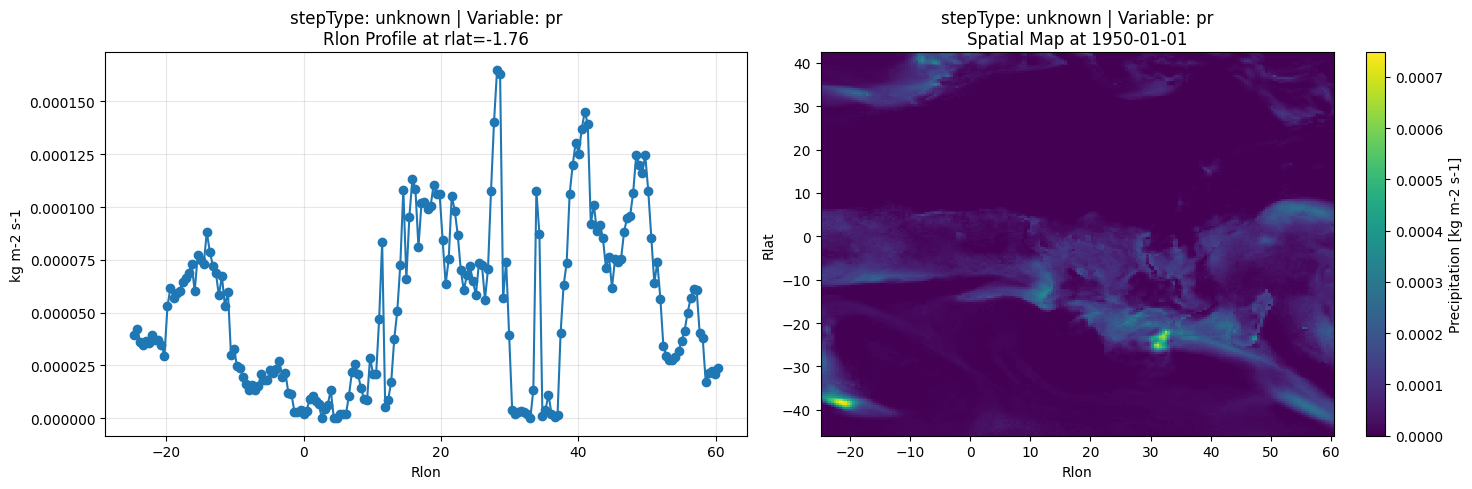

In [19]:
# Get the first variable name from the dataset
first_var = list(ds.data_vars)[0]
print(f"Plotting: {first_var}")

# Plot the first variable for the first time step
fig = plot_cordex_variable(ds, first_var, time_index=0)
plt.show()

### Plot All Variables

Now let's create a comprehensive view of all variables for the first day:

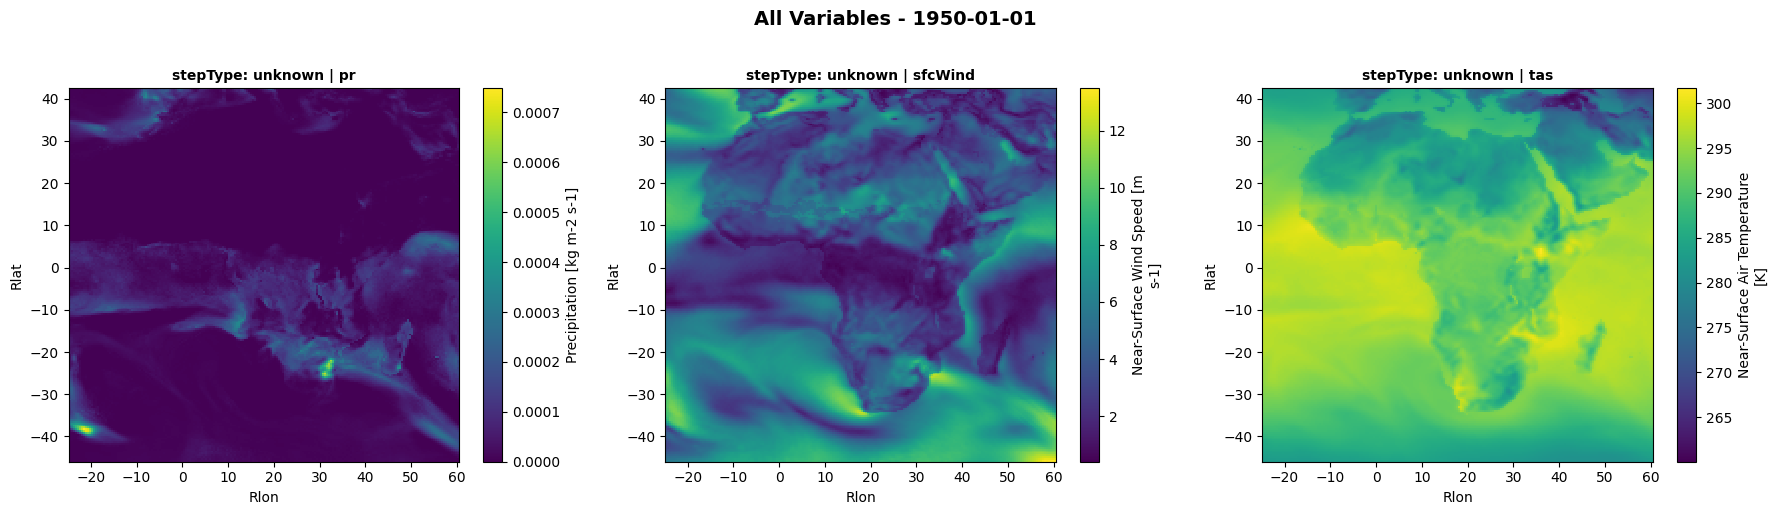

In [21]:
# Plot all variables for the first day
fig = plot_cordex_variables_comparison(ds, time_index=0)
plt.show()